# preprocess_after_project

#### 시작 전 세팅

In [18]:
# 기본 라이브러리
import ast
import sys
import itertools
from collections import Counter
from pathlib import Path

# 데이터 처리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
from IPython.display import display
from wordcloud import WordCloud

# 분석 모델
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

In [19]:
# 현재 작업 폴더가 notebooks/ 이든 프로젝트 루트이든
# project_paths.py 를 기준으로 루트를 자동으로 찾습니다.
root = Path.cwd()

while not (root / "project_paths.py").exists() and root != root.parent:
    root = root.parent

# import 가능하도록 sys.path 에 루트를 추가합니다.
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("프로젝트 루트:", root)

프로젝트 루트: c:\Increase-in-medical-school-seats


In [20]:
# 프로젝트에서 공통으로 쓰는 경로 상수를 불러옵니다.
from project_paths import (
    CONFIG_STOPWORDS,
    DATA_INTEGRATED,
    OUTPUTS_PIPELINE,
    OUTPUTS_PIPELINE_KMEANS,
    OUTPUTS_PIPELINE_LDA,
    OUTPUTS_PIPELINE_TFIDF,
    OUTPUTS_PIPELINE_WORDCLOUD_FILTERED,
    OUTPUTS_PIPELINE_WORDCLOUD_RAW,
    ensure_output_dirs,
)

# 결과 저장 폴더가 없으면 만들어 둡니다.
ensure_output_dirs()

print("통합 데이터 폴더:", DATA_INTEGRATED)
print("불용어 폴더:", CONFIG_STOPWORDS)
print("결과 저장 폴더:", OUTPUTS_PIPELINE)

통합 데이터 폴더: C:\Increase-in-medical-school-seats\data\integrated
불용어 폴더: C:\Increase-in-medical-school-seats\config\stopwords
결과 저장 폴더: C:\Increase-in-medical-school-seats\outputs\pipeline


In [21]:
# 경로 설정

# 분석 시작 파일
# 이 파일은 명사 컬럼이 이미 리스트 형태라서 바로 분석에 쓰기 좋습니다.
INPUT_FILE = DATA_INTEGRATED / "combined_section_sorted_flat_comments.pkl"

# 불용어 파일
# 지금은 미리 모아둔 최종 제외어 파일을 사용합니다.
STOPWORDS_FILE = CONFIG_STOPWORDS / "analysis_stopwords_excluded.txt"

# 제목 명사까지 포함할지 여부
# False 면 본문 + 댓글만 사용합니다.
INCLUDE_TITLE_NOUNS = False

# 워드클라우드 한글 폰트 경로
FONT_PATH = "C:/Windows/Fonts/malgun.ttf"

# TF-IDF 전체 상위 단어 개수
TFIDF_TOP_N = 30

# K-means 클러스터 개수
KMEANS_N_CLUSTERS = 5

# LDA 토픽 개수
LDA_N_TOPICS = 5

# LDA 에서 토픽별 상위 단어 개수
LDA_TOP_WORDS = 15

In [23]:
# 문자열로 저장된 리스트를 실제 리스트로 바꾸는 함수입니다.
# 이미 리스트면 그대로 반환합니다.
def ensure_token_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            parsed = ast.literal_eval(x)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []

# txt 파일에서 불용어를 한 줄씩 읽는 함수입니다.
def load_stopwords(path):
    return [
        line.strip()
        for line in path.read_text(encoding="utf-8-sig").splitlines()
        if line.strip()
    ]


In [43]:
# 워드클라우드를 화면에 보여주고, 원하면 png 파일로 저장하는 함수입니다.
def make_wordcloud(counter, title, output_file=None):
    wc = WordCloud(
        font_path=FONT_PATH,
        background_color="white",
        width=1400,
        height=900
    ).generate_from_frequencies(dict(counter))

    plt.figure(figsize=(12, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

    if output_file is not None:
        wc.to_file(str(output_file))

    return wc


# 4구간 라벨
SECTION_LABELS = {
    1: "1구간 (2024-01-01 ~ 2024-03-31)",
    2: "2구간 (2024-04-01 ~ 2024-06-30)",
    3: "3구간 (2024-07-01 ~ 2024-12-31)",
    4: "4구간 (2025-01-01 ~ 2025-06-30)"
}


# section 단위로 명사를 하나의 문서처럼 묶는 함수입니다.
# token_col 에 full_nouns_raw 또는 full_nouns_filtered 를 넣어서 사용합니다.
def build_section_df(source_df, token_col):
    section_df = (
        source_df.sort_values(["section", "date"])
        .groupby("section")
        .agg(
            period_start=("date", "min"),
            period_end=("date", "max"),
            post_count=(token_col, "size"),
            all_nouns=(token_col, lambda rows: list(itertools.chain.from_iterable(rows)))
        )
        .reset_index()
    )

    section_df["section_doc"] = section_df["all_nouns"].apply(lambda tokens: " ".join(tokens))
    section_df["section_label"] = section_df["section"].apply(
        lambda x: SECTION_LABELS.get(int(x), f"{x}구간")
    )

    return section_df

### 1. 전처리된 파일 불러오기

In [25]:
# 분석에 사용할 전처리 완료 파일을 불러옵니다.
print("불러올 파일:", INPUT_FILE)
print("파일 존재 여부:", INPUT_FILE.exists())

df = pd.read_pickle(INPUT_FILE).copy()

# 날짜 컬럼은 시계열 분석과 section 정렬에 쓰기 때문에 datetime 으로 바꿉니다.
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("데이터 크기:", df.shape)
display(df.head(5))

불러올 파일: C:\Increase-in-medical-school-seats\data\integrated\combined_section_sorted_flat_comments.pkl
파일 존재 여부: True
데이터 크기: (8972, 11)


,title,doc,like,comment_cnt,comment_list,ch,date,section,title_token_noun,document_token_noun,comment_token_noun
0,병원 남은 참의사들 신상 조롱 퍼지자 일부 전공의 존중 해야,의대정원 증원에 반발한 전공의들이 진료거부를 이어가고 있는 지난 5일 오전 서울시 ...,8,2,[{'comment_content': '입시도사님 오늘도 방문했어요 정성스럽게 쓰신...,blog,2024-03-10,1,"[병원, 의사, 신상, 조롱, 일부, 전공의, 존중]","[의대, 정원, 증원, 반발, 전공의, 진료, 거부, 오전, 서울시, 병원, 의료진...","[입시, 도사, 오늘, 방문, 정성, 월요일, 방문, 전공의, 희생, 노력, 감사,..."
1,지방 의대 증원과 변경될 지역인재전형 의대 입시 어떻게 바뀔까,2024년 3월 20일 오후 2시 교육부를 통해 발표된 대학별 의대 증원에 대한 소...,122,3,[{'comment_content': '요즘 정말 이슈이던데 앞으로 어떻게 바뀔지가...,blog,2024-03-21,1,"[지방, 의대, 증원, 변경, 지역, 인재, 전형, 의대, 입시]","[오후, 교육부, 발표, 대학, 의대, 증원, 소식, 사교육, 수험, 감자, 의대,...","[요즘, 이슈]"
2,의대증원 발표 이유 의대가려면 어디로,안녕하세요 요새 뜨거운 감자가 된 의대정원 증원과 관련된 소식입니다 아마 의대정원 ...,147,8,[{'comment_content': '포스팅 잘보고 갑니다 제 맛집블로그 구경오세...,blog,2024-03-21,1,"[의대, 증원, 발표, 이유, 의대]","[안녕, 감자, 의대, 정원, 증원, 관련, 소식, 의대, 정원, 증원, 반대, 내...","[포스팅, 맛집, 블로그, 구경, 의대, 정원, 관련, 의견, 대립, 양보, 결과,..."
3,정부 의대 증원 2000명 중 82 1639명 비수도권 지방 의대에 배정 서울권 의...,안녕하세요 각종 뉴스를 분석해서 알려드리는 뉴스분석타파 입니다 의대 증원은 국가의 ...,63,3,[{'comment_content': '해피멘 Happy Men님께서 정성스럽게 쓰...,blog,2024-03-21,1,"[정부, 의대, 증원, 수도, 지방, 의대, 배정, 서울, 의대]","[안녕, 각종, 뉴스, 분석, 뉴스, 분석, 타파, 의대, 증원, 국가, 의료, 체...","[해피멘, 정성, 포스팅, 블로그, 답방, 건강, 하루]"
4,의대증원 2000명 지역별 시뮬레이션 실제 권역별로 얼마나 늘어나고 변화했을까,의대 정원 2000명 대학별 배정이 완료되었습니다 서울은 0 경인은 18 를 비수도...,40,14,"[{'comment_content': '빠르시네요 좋은 정보 감사합니다', 'com...",blog,2024-03-21,1,"[의대, 증원, 지역, 시뮬레이션, 실제, 권역, 변화]","[의대, 정원, 대학, 배정, 완료, 서울, 경인, 수도, 증가, 지역, 발전, 고...","[정보, 감사, 지역, 의대, 준비, 학생, 컨설팅, 중요, 정보, 방문, 감사, 자료]"


In [26]:
# 명사 컬럼이 혹시 문자열 상태여도 안전하게 리스트로 맞춰줍니다.
noun_cols = ["title_token_noun", "document_token_noun", "comment_token_noun"]

for col in noun_cols:
    df[col] = df[col].apply(ensure_token_list)

# 확인용 출력
for col in noun_cols:
    print(col, type(df[col].iloc[0]), df[col].iloc[0][:10])

title_token_noun <class 'list'> ['병원', '의사', '신상', '조롱', '일부', '전공의', '존중']
document_token_noun <class 'list'> ['의대', '정원', '증원', '반발', '전공의', '진료', '거부', '오전', '서울시', '병원']
comment_token_noun <class 'list'> ['입시', '도사', '오늘', '방문', '정성', '월요일', '방문', '전공의', '희생', '노력']


### 2. 원본 명사 만들기

In [27]:
# 기본 분석용 명사 컬럼을 만듭니다.
# 기본값은 본문 + 댓글 명사입니다.
# 제목도 포함하고 싶으면 INCLUDE_TITLE_NOUNS = True 로 바꾸면 됩니다.
if INCLUDE_TITLE_NOUNS:
    df["full_nouns_raw"] = (
        df["title_token_noun"]
        + df["document_token_noun"]
        + df["comment_token_noun"]
    )
else:
    df["full_nouns_raw"] = (
        df["document_token_noun"]
        + df["comment_token_noun"]
    )

# 벡터화에 쓰기 쉽게 공백으로 이어붙인 문자열 문서도 같이 만듭니다.
df["doc_text_raw"] = df["full_nouns_raw"].apply(lambda tokens: " ".join(tokens))

display(df[["title", "section", "full_nouns_raw"]].head())

,title,section,full_nouns_raw
0,병원 남은 참의사들 신상 조롱 퍼지자 일부 전공의 존중 해야,1,"[의대, 정원, 증원, 반발, 전공의, 진료, 거부, 오전, 서울시, 병원, 의료진..."
1,지방 의대 증원과 변경될 지역인재전형 의대 입시 어떻게 바뀔까,1,"[오후, 교육부, 발표, 대학, 의대, 증원, 소식, 사교육, 수험, 감자, 의대,..."
2,의대증원 발표 이유 의대가려면 어디로,1,"[안녕, 감자, 의대, 정원, 증원, 관련, 소식, 의대, 정원, 증원, 반대, 내..."
3,정부 의대 증원 2000명 중 82 1639명 비수도권 지방 의대에 배정 서울권 의...,1,"[안녕, 각종, 뉴스, 분석, 뉴스, 분석, 타파, 의대, 증원, 국가, 의료, 체..."
4,의대증원 2000명 지역별 시뮬레이션 실제 권역별로 얼마나 늘어나고 변화했을까,1,"[의대, 정원, 대학, 배정, 완료, 서울, 경인, 수도, 증가, 지역, 발전, 고..."


### 3. 불용어 처리 전 워드 클라우드

In [48]:
# 불용어 처리 전 워드클라우드는 전체 1장이 아니라 section별 4개로 만듭니다.
section_raw_df = build_section_df(df, "full_nouns_raw")

display(
    section_raw_df[["section", "section_label", "period_start", "period_end", "post_count"]]
)

,section,section_label,period_start,period_end,post_count
0,1,1구간 (2024-01-01 ~ 2024-03-31),2024-01-01,2024-03-31,2303
1,2,2구간 (2024-04-01 ~ 2024-06-30),2024-04-01,2024-06-30,2419
2,3,3구간 (2024-07-01 ~ 2024-12-31),2024-07-01,2024-12-31,3017
3,4,4구간 (2025-01-01 ~ 2025-06-30),2025-01-01,2025-06-30,1233



===== 1구간 (2024-01-01 ~ 2024-03-31) 불용어 처리 전 상위 단어 =====


,keyword,count
0,의사,20006
1,의대,19659
2,의료,14485
3,증원,12573
4,정부,8994
5,병원,7278
6,정원,7060
7,대학,6127
8,생각,5318
9,지역,5246


c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabto

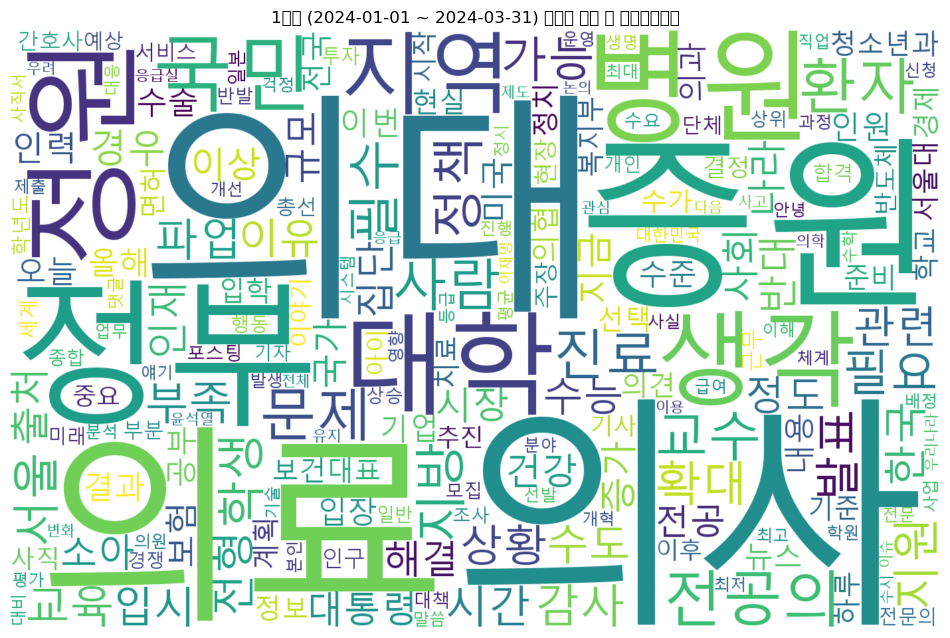


===== 2구간 (2024-04-01 ~ 2024-06-30) 불용어 처리 전 상위 단어 =====


,keyword,count
0,의대,16324
1,증원,10501
2,의사,8986
3,의료,8778
4,정부,6846
5,대학,6610
6,전형,4822
7,지역,4365
8,병원,4302
9,정원,4230


c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabto

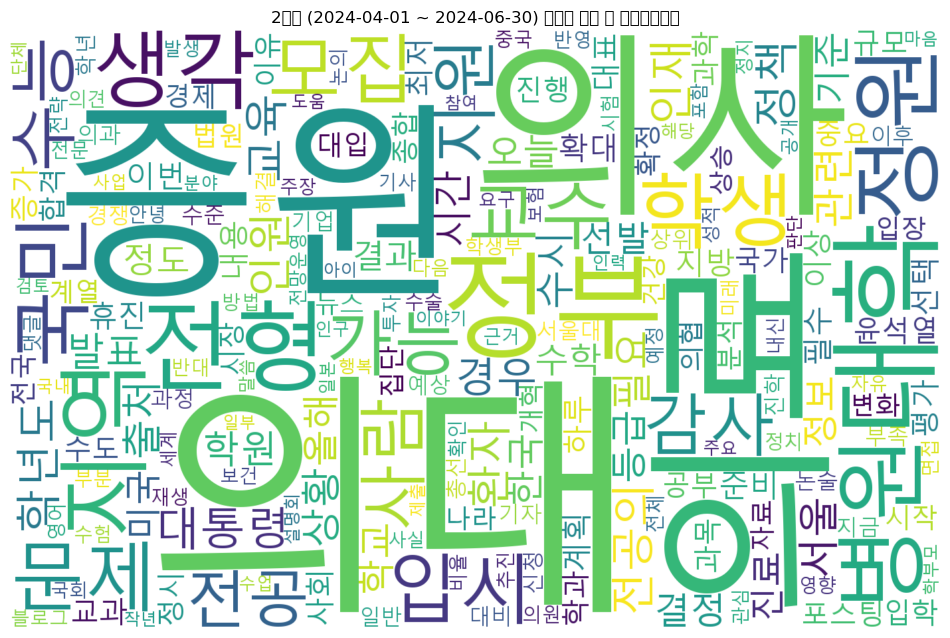


===== 3구간 (2024-07-01 ~ 2024-12-31) 불용어 처리 전 상위 단어 =====


,keyword,count
0,의대,16161
1,의료,10562
2,의사,10144
3,증원,8836
4,대학,7364
5,정부,6601
6,병원,6208
7,전형,5587
8,수능,5328
9,학생,5167


c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabto

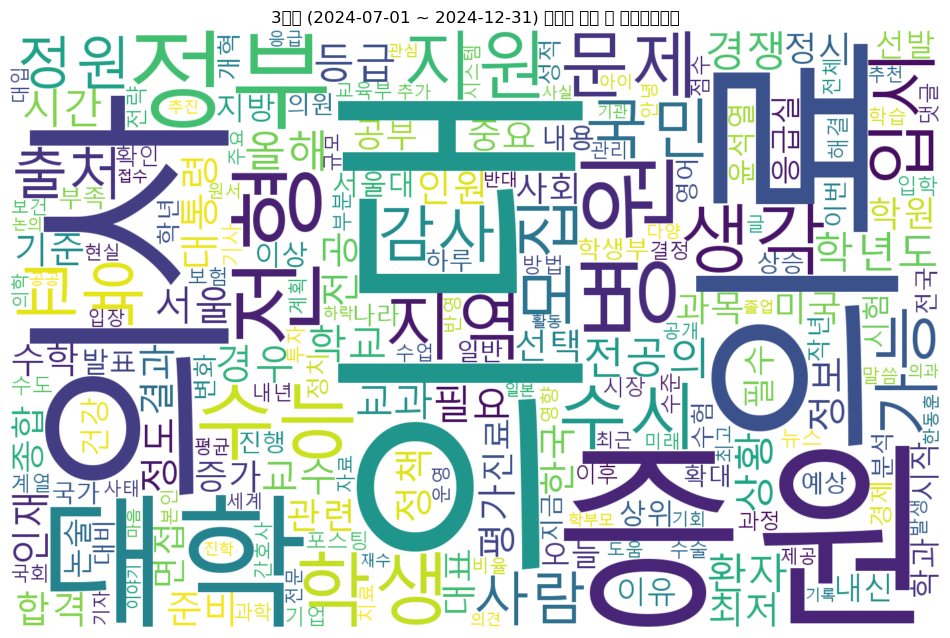


===== 4구간 (2025-01-01 ~ 2025-06-30) 불용어 처리 전 상위 단어 =====


,keyword,count
0,의대,7865
1,증원,3411
2,의사,3213
3,대학,3050
4,의료,2832
5,생각,2362
6,감사,2260
7,전형,2197
8,학생,2183
9,출처,2154


c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabto

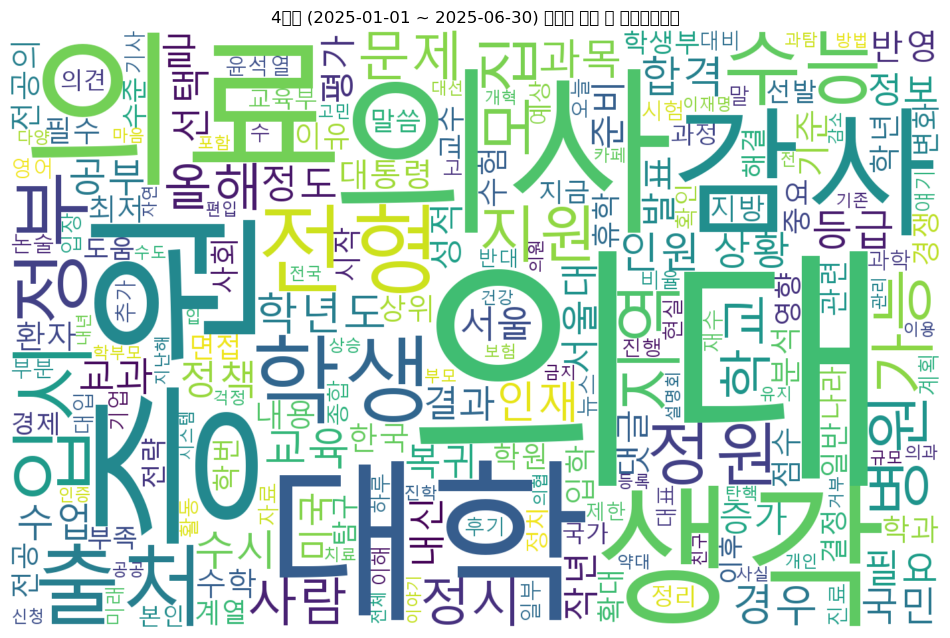

In [49]:
# 각 구간별 불용어 처리 전 상위 단어와 워드클라우드를 생성합니다.
for _, row in section_raw_df.iterrows():
    sec = int(row["section"])
    label = row["section_label"]

    counter = Counter(row["all_nouns"])

    top_df = pd.DataFrame(
        counter.most_common(100),
        columns=["keyword", "count"]
    )

    print(f"\n===== {label} 불용어 처리 전 상위 단어 =====")
    display(top_df.head(20))

    make_wordcloud(
        counter,
        title=f"{label} 불용어 처리 전 워드클라우드",
        output_file=OUTPUTS_PIPELINE_WORDCLOUD_RAW / f"wordcloud_raw_section_{sec}.png"
    )

    top_df.to_csv(
        OUTPUTS_PIPELINE_WORDCLOUD_RAW / f"wordcloud_raw_top100_section_{sec}.csv",
        index=False,
        encoding="utf-8-sig"
    )

### 4. 불용어 파일 불러오기

In [50]:
# 미리 만들어 둔 최종 불용어 파일을 읽습니다. --
print("불용어 파일:", STOPWORDS_FILE)
print("파일 존재 여부:", STOPWORDS_FILE.exists())

stopwords = set(load_stopwords(STOPWORDS_FILE))

print("불용어 개수:", len(stopwords))
print(sorted(list(stopwords))[:50])

불용어 파일: C:\Increase-in-medical-school-seats\config\stopwords\analysis_stopwords_excluded.txt
파일 존재 여부: True
불용어 개수: 221
['가능', '감사', '감소', '개인', '개혁', '걱정', '건강', '결과', '결정', '경우', '경쟁', '경제', '계열', '계획', '공감', '공개', '공부', '과목', '과정', '과학', '관련', '관리', '관심', '교과', '교수', '교육', '교육부', '구경', '국가', '국민', '규모', '근거', '글', '기사', '기업', '기자', '기준', '나라', '내년', '내신', '내용', '논술', '논의', '뉴스', '답방', '대비', '대입', '대통령', '대표', '대학']


### 5. 불용어 적용

In [51]:
# 원본 명사에서 불용어를 제거한 최종 분석용 명사 컬럼을 만듭니다. --
df["full_nouns_filtered"] = df["full_nouns_raw"].apply(
    lambda tokens: [token for token in tokens if token not in stopwords]
)

# TF-IDF, K-means, LDA 에 쓸 문자열 문서도 만듭니다.
df["doc_text_filtered"] = df["full_nouns_filtered"].apply(lambda tokens: " ".join(tokens))

display(df[["title", "full_nouns_filtered"]].head())

,title,full_nouns_filtered
0,병원 남은 참의사들 신상 조롱 퍼지자 일부 전공의 존중 해야,"[반발, 거부, 오전, 서울시, 의료진, 이동, 반발, 행동, 사이, 현장, 비난,..."
1,지방 의대 증원과 변경될 지역인재전형 의대 입시 어떻게 바뀔까,"[오후, 소식, 사교육, 감자, 로드맵, 전문가, 현장, 전문가, 변경, 반응, 갈..."
2,의대증원 발표 이유 의대가려면 어디로,"[감자, 소식, 사직, 거부, 사유, 인프라, 확충, 사이, 격차, 인구, 격차, ..."
3,정부 의대 증원 2000명 중 82 1639명 비수도권 지방 의대에 배정 서울권 의...,"[각종, 타파, 체계, 조정, 인프라, 균형, 서비스, 제공, 배정, 배정, 분배,..."
4,의대증원 2000명 지역별 시뮬레이션 실제 권역별로 얼마나 늘어나고 변화했을까,"[배정, 완료, 경인, 발전, 고려, 고등학생, 자신, 실질, 혜택, 단계, 시뮬레..."


In [52]:
# 불용어 처리 후 명사를 다시 펼쳐서 빈도를 계산합니다.
filtered_tokens = list(itertools.chain.from_iterable(df["full_nouns_filtered"]))
filtered_counter = Counter(filtered_tokens)

filtered_top100 = pd.DataFrame(
    filtered_counter.most_common(100),
    columns=["keyword", "count"]
)

display(filtered_top100.head(20))

,keyword,count
0,치료,3413
1,미래,3406
2,투자,3309
3,주장,3200
4,발생,3139
5,간호사,3131
6,시스템,3024
7,최고,3002
8,아이,2979
9,현장,2910


### 6. 불용어 처리 후 워드클라우드

In [53]:
# 불용어 처리 후 워드클라우드도 section별 4개로 만듭니다.
section_filtered_df = build_section_df(df, "full_nouns_filtered")

display(
    section_filtered_df[["section", "section_label", "period_start", "period_end", "post_count"]]
)

,section,section_label,period_start,period_end,post_count
0,1,1구간 (2024-01-01 ~ 2024-03-31),2024-01-01,2024-03-31,2303
1,2,2구간 (2024-04-01 ~ 2024-06-30),2024-04-01,2024-06-30,2419
2,3,3구간 (2024-07-01 ~ 2024-12-31),2024-07-01,2024-12-31,3017
3,4,4구간 (2025-01-01 ~ 2025-06-30),2025-01-01,2025-06-30,1233



===== 1구간 (2024-01-01 ~ 2024-03-31) 불용어 처리 후 상위 단어 =====


,keyword,count
0,치료,1214
1,면허,1213
2,수가,1211
3,사직,1203
4,반도체,1150
5,현장,1142
6,아이,1141
7,주장,1137
8,간호사,1112
9,근무,1094


c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabto

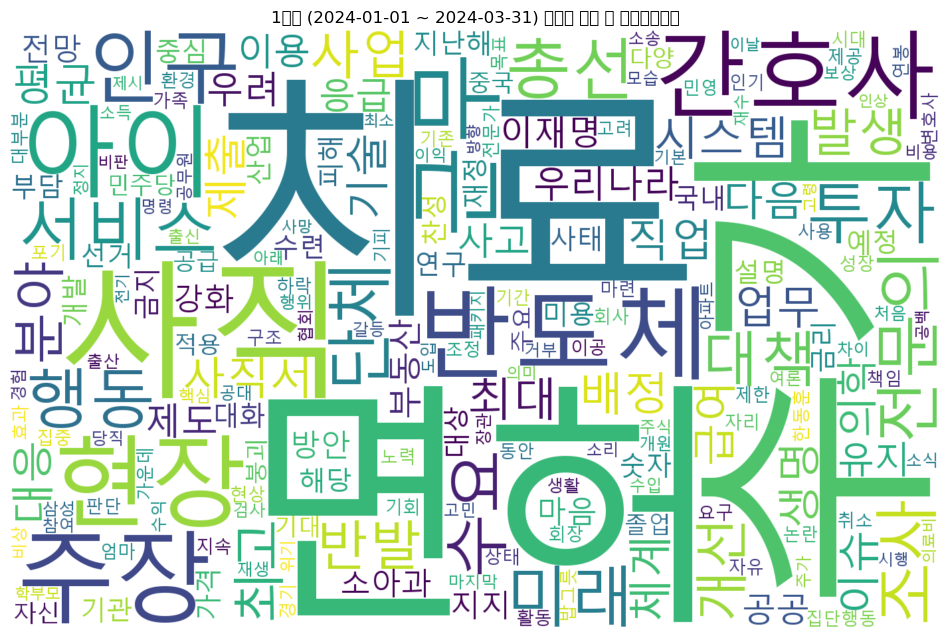


===== 2구간 (2024-04-01 ~ 2024-06-30) 불용어 처리 후 상위 단어 =====


,keyword,count
0,총선,1098
1,재생,970
2,미래,938
3,다음,931
4,투자,923
5,예정,920
6,중국,913
7,자유,859
8,주장,850
9,국회,848


c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabto

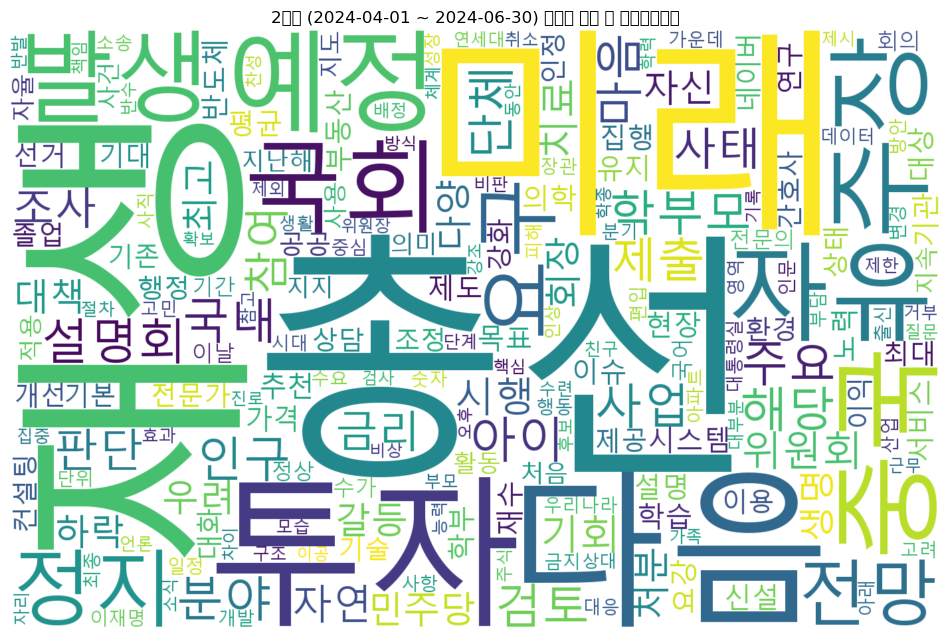


===== 3구간 (2024-07-01 ~ 2024-12-31) 불용어 처리 후 상위 단어 =====


,keyword,count
0,국회,1211
1,학습,1186
2,치료,1136
3,간호사,1111
4,최고,1076
5,투자,1074
6,발생,1071
7,시스템,1057
8,평균,1055
9,미래,1052


c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabto

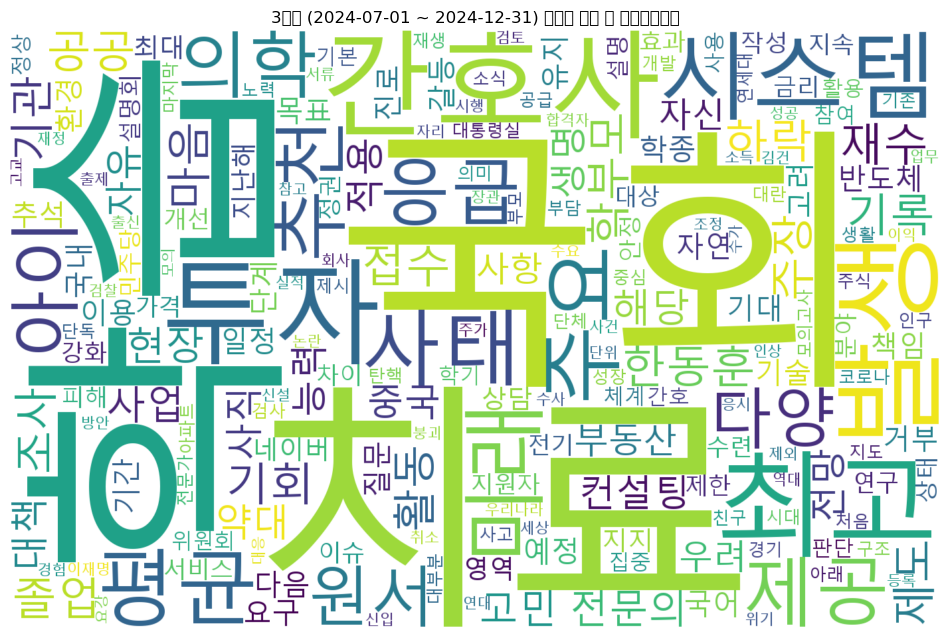


===== 4구간 (2025-01-01 ~ 2025-06-30) 불용어 처리 후 상위 단어 =====


,keyword,count
0,재수,439
1,고,410
2,제한,410
3,후기,406
4,활동,403
5,미래,399
6,수,396
7,이재명,395
8,인증,382
9,과탐,381


c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabto

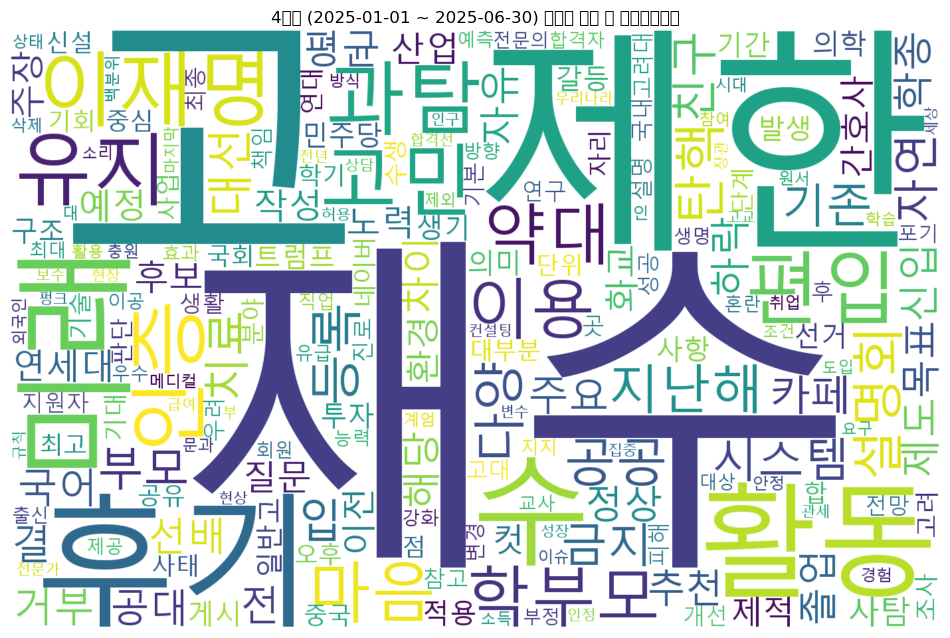

In [54]:
# 각 구간별 불용어 처리 후 상위 단어와 워드클라우드를 생성합니다.
for _, row in section_filtered_df.iterrows():
    sec = int(row["section"])
    label = row["section_label"]

    counter = Counter(row["all_nouns"])

    top_df = pd.DataFrame(
        counter.most_common(100),
        columns=["keyword", "count"]
    )

    print(f"\n===== {label} 불용어 처리 후 상위 단어 =====")
    display(top_df.head(20))

    make_wordcloud(
        counter,
        title=f"{label} 불용어 처리 후 워드클라우드",
        output_file=OUTPUTS_PIPELINE_WORDCLOUD_FILTERED / f"wordcloud_filtered_section_{sec}.png"
    )

    top_df.to_csv(
        OUTPUTS_PIPELINE_WORDCLOUD_FILTERED / f"wordcloud_filtered_top100_section_{sec}.csv",
        index=False,
        encoding="utf-8-sig"
    )

### 7. TF-IDF

In [55]:
# TF-IDF는 전체 문서 평균이 아니라 section_df 기준 4구간 비교로 계산합니다.
section_df = build_section_df(df, "full_nouns_filtered")

display(
    section_df[["section", "section_label", "period_start", "period_end", "post_count"]]
)

,section,section_label,period_start,period_end,post_count
0,1,1구간 (2024-01-01 ~ 2024-03-31),2024-01-01,2024-03-31,2303
1,2,2구간 (2024-04-01 ~ 2024-06-30),2024-04-01,2024-06-30,2419
2,3,3구간 (2024-07-01 ~ 2024-12-31),2024-07-01,2024-12-31,3017
3,4,4구간 (2025-01-01 ~ 2025-06-30),2025-01-01,2025-06-30,1233


In [56]:
# 4개 구간 문서를 TF-IDF 행렬로 변환합니다.
section_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    min_df=1,
    max_df=1.0
)

section_tfidf_matrix = section_vectorizer.fit_transform(section_df["section_doc"])
section_features = np.array(section_vectorizer.get_feature_names_out())

print("구간별 TF-IDF 행렬 크기:", section_tfidf_matrix.shape)
print("단어 수:", len(section_features))

구간별 TF-IDF 행렬 크기: (4, 64815)
단어 수: 64815


In [57]:
# 각 구간별 TF-IDF 상위 단어를 추출합니다.
section_tfidf_rows = []

for row_idx, row in section_df.iterrows():
    scores = section_tfidf_matrix[row_idx].toarray().ravel()
    top_idx = scores.argsort()[::-1][:20]

    for rank, idx in enumerate(top_idx, start=1):
        section_tfidf_rows.append({
            "section": int(row["section"]),
            "section_label": row["section_label"],
            "rank": rank,
            "keyword": section_features[idx],
            "tfidf": scores[idx]
        })

section_tfidf_top = pd.DataFrame(section_tfidf_rows)

display(section_tfidf_top.head(40))

section_tfidf_top.to_csv(
    OUTPUTS_PIPELINE_TFIDF / "tfidf_top_terms_by_section.csv",
    index=False,
    encoding="utf-8-sig"
)

,section,section_label,rank,keyword,tfidf
0,1,1구간 (2024-01-01 ~ 2024-03-31),1,치료,0.092664
1,1,1구간 (2024-01-01 ~ 2024-03-31),2,면허,0.092588
2,1,1구간 (2024-01-01 ~ 2024-03-31),3,수가,0.092435
3,1,1구간 (2024-01-01 ~ 2024-03-31),4,사직,0.091825
4,1,1구간 (2024-01-01 ~ 2024-03-31),5,반도체,0.087779
5,1,1구간 (2024-01-01 ~ 2024-03-31),6,아이,0.087321
6,1,1구간 (2024-01-01 ~ 2024-03-31),7,현장,0.087169
7,1,1구간 (2024-01-01 ~ 2024-03-31),8,주장,0.086787
8,1,1구간 (2024-01-01 ~ 2024-03-31),9,간호사,0.084879
9,1,1구간 (2024-01-01 ~ 2024-03-31),10,근무,0.083505


### 8. K-means

In [65]:
# 엘보우 그래프를 본 뒤 최종 K를 지정합니다.
# 현재 데이터는 대부분 2 -> 3에서 SSE 감소폭이 가장 크므로 기본값을 3으로 둡니다.
# 필요하면 특정 구간만 4로 바꿔서 다시 비교할 수 있습니다.

KMEANS_SECTION_K = {
    1: 3,
    2: 3,
    3: 3,
    4: 3
}

display(
    pd.DataFrame(
        {
            "section": list(KMEANS_SECTION_K.keys()),
            "chosen_k": list(KMEANS_SECTION_K.values())
        }
    )
)

,section,chosen_k
0,1,3
1,2,3
2,3,3
3,4,3


c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


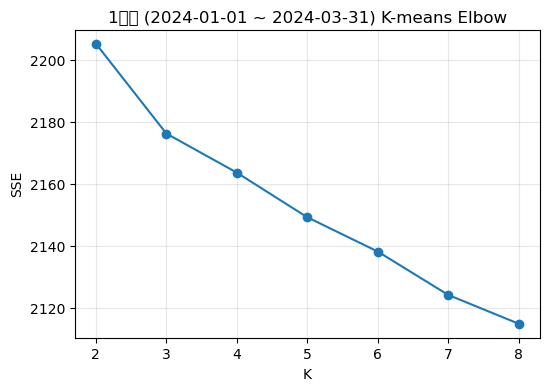

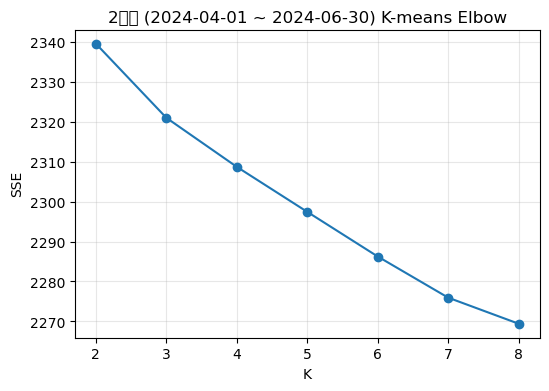

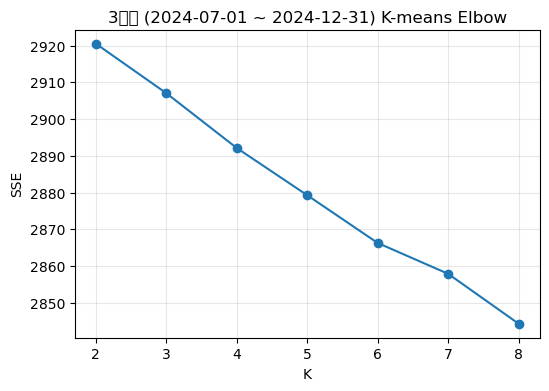

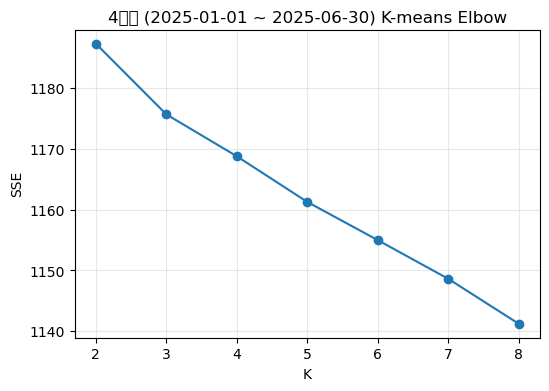

,section,section_label,k,sse
0,1,1구간 (2024-01-01 ~ 2024-03-31),2,2205.119652
1,1,1구간 (2024-01-01 ~ 2024-03-31),3,2176.213717
2,1,1구간 (2024-01-01 ~ 2024-03-31),4,2163.641423
3,1,1구간 (2024-01-01 ~ 2024-03-31),5,2149.281708
4,1,1구간 (2024-01-01 ~ 2024-03-31),6,2138.251333
5,1,1구간 (2024-01-01 ~ 2024-03-31),7,2124.297858
6,1,1구간 (2024-01-01 ~ 2024-03-31),8,2115.025281
7,2,2구간 (2024-04-01 ~ 2024-06-30),2,2339.504723
8,2,2구간 (2024-04-01 ~ 2024-06-30),3,2320.960175
9,2,2구간 (2024-04-01 ~ 2024-06-30),4,2308.682506


In [64]:
# section별 K-means 엘보우 그래프를 그립니다.
# 각 구간 안의 개별 문서들을 TF-IDF로 벡터화한 뒤 SSE를 비교합니다.

analysis_df = df[df["doc_text_filtered"].str.strip() != ""].copy().reset_index(drop=True)

elbow_result_list = []

for sec in sorted(analysis_df["section"].dropna().unique()):
    sec = int(sec)
    sec_df = analysis_df[analysis_df["section"] == sec].copy().reset_index(drop=True)
    label = SECTION_LABELS.get(sec, f"{sec}구간")

    if len(sec_df) < 3:
        print(f"{label}: 문서 수가 너무 적어서 엘보우 그래프를 건너뜁니다.")
        continue

    vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=5,
        max_df=0.85
    )

    try:
        X = vectorizer.fit_transform(sec_df["doc_text_filtered"])
    except ValueError as e:
        print(f"{label}: {e}")
        continue

    # K는 보통 2~8 범위에서 탐색하되,
    # 문서 수나 단어 수보다 크게 잡지 않도록 제한합니다.
    max_k = min(8, X.shape[0], X.shape[1])

    if max_k < 2:
        print(f"{label}: 가능한 K가 없어서 건너뜁니다.")
        continue

    k_values = list(range(2, max_k + 1))
    sse = []

    for k in k_values:
        km = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=42
        )
        km.fit(X)
        sse.append(km.inertia_)

    elbow_df = pd.DataFrame({
        "section": sec,
        "section_label": label,
        "k": k_values,
        "sse": sse
    })

    elbow_result_list.append(elbow_df)

    # 엘보우 그래프 출력
    plt.figure(figsize=(6, 4))
    plt.plot(k_values, sse, marker="o")
    plt.title(f"{label} K-means Elbow")
    plt.xlabel("K")
    plt.ylabel("SSE")
    plt.xticks(k_values)
    plt.grid(alpha=0.3)
    plt.show()

# 전체 엘보우 결과 표로 확인
if elbow_result_list:
    elbow_result_df = pd.concat(elbow_result_list, ignore_index=True)
    display(elbow_result_df)

    elbow_result_df.to_csv(
        OUTPUTS_PIPELINE_KMEANS / "kmeans_elbow_by_section.csv",
        index=False,
        encoding="utf-8-sig"
    )
else:
    print("저장할 엘보우 결과가 없습니다.")

In [66]:
# K-means는 전체 문서를 한 번에 하지 않고 각 구간 안에서 따로 수행합니다.
# K 값은 위에서 정한 KMEANS_SECTION_K 를 사용합니다.

analysis_df = df[df["doc_text_filtered"].str.strip() != ""].copy().reset_index(drop=True)

kmeans_result_list = []
kmeans_terms_list = []

for sec in sorted(analysis_df["section"].dropna().unique()):
    sec = int(sec)
    sec_df = analysis_df[analysis_df["section"] == sec].copy().reset_index(drop=True)
    label = SECTION_LABELS.get(sec, f"{sec}구간")

    if len(sec_df) < 2:
        print(f"{label}: 문서 수가 너무 적어서 건너뜁니다.")
        continue

    vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=5,
        max_df=0.85
    )

    try:
        sec_tfidf_matrix = vectorizer.fit_transform(sec_df["doc_text_filtered"])
    except ValueError as e:
        print(f"{label}: {e}")
        continue

    features = np.array(vectorizer.get_feature_names_out())

    if len(features) == 0:
        print(f"{label}: 남은 단어가 없어서 건너뜁니다.")
        continue

    # 구간별로 미리 정한 K 사용
    requested_k = KMEANS_SECTION_K.get(sec, 3)

    # 문서 수나 단어 수보다 크게 잡히지 않도록 안전하게 제한
    n_clusters = min(requested_k, len(sec_df), len(features))

    if n_clusters < 2:
        print(f"{label}: 클러스터 수를 만들 수 없어서 건너뜁니다.")
        continue

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=20
    )

    sec_df["cluster"] = kmeans.fit_predict(sec_tfidf_matrix)
    sec_df["section_label"] = label

    kmeans_result_list.append(
        sec_df[["section", "section_label", "date", "title", "cluster"]]
    )

    # 각 클러스터의 대표 단어 추출
    for cluster_id in range(n_clusters):
        centroid = kmeans.cluster_centers_[cluster_id]
        top_idx = centroid.argsort()[::-1][:15]
        cluster_size = int((sec_df["cluster"] == cluster_id).sum())

        for rank, idx in enumerate(top_idx, start=1):
            kmeans_terms_list.append({
                "section": sec,
                "section_label": label,
                "cluster": cluster_id,
                "cluster_size": cluster_size,
                "rank": rank,
                "keyword": features[idx],
                "weight": centroid[idx]
            })


In [67]:
# 구간별 K-means 결과를 합치고 저장합니다.
if kmeans_result_list:
    kmeans_doc_assignments = pd.concat(kmeans_result_list, ignore_index=True)
    kmeans_cluster_terms = pd.DataFrame(kmeans_terms_list)

    display(kmeans_cluster_terms.head(30))
    display(kmeans_doc_assignments.head(10))

    kmeans_cluster_terms.to_csv(
        OUTPUTS_PIPELINE_KMEANS / "kmeans_cluster_top_terms_by_section.csv",
        index=False,
        encoding="utf-8-sig"
    )

    kmeans_doc_assignments.to_csv(
        OUTPUTS_PIPELINE_KMEANS / "kmeans_doc_assignments_by_section.csv",
        index=False,
        encoding="utf-8-sig"
    )
else:
    print("저장할 K-means 결과가 없습니다.")

,section,section_label,cluster,cluster_size,rank,keyword,weight
0,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,1,아이,0.260412
1,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,2,당직,0.210359
2,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,3,엄마,0.194028
3,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,4,환아,0.168419
4,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,5,소청,0.160560
5,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,6,세브란스,0.148443
6,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,7,근무,0.128710
7,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,8,붕괴,0.120515
8,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,9,소아청소년과,0.119141
9,1,1구간 (2024-01-01 ~ 2024-03-31),0,61,10,포기,0.087476


,section,section_label,date,title,cluster
0,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-10,병원 남은 참의사들 신상 조롱 퍼지자 일부 전공의 존중 해야,2
1,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-21,지방 의대 증원과 변경될 지역인재전형 의대 입시 어떻게 바뀔까,1
2,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-21,의대증원 발표 이유 의대가려면 어디로,1
3,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-21,정부 의대 증원 2000명 중 82 1639명 비수도권 지방 의대에 배정 서울권 의...,1
4,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-21,의대증원 2000명 지역별 시뮬레이션 실제 권역별로 얼마나 늘어나고 변화했을까,1
5,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-21,전주독학재수학원 전북대 의대 정원 142명 200명 증원 지거국 중 증원 수 가장 적음,1
6,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-21,충북대 의대 정원 151명 증가 전국 최다 증원 충주 충북대병원 가속화,1
7,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-21,의대 정원 증원으로 의정 갈등 속의 의료개혁 돌파구,1
8,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-21,공유 이슈 의대 증원 2000명 중 서울권 의대 0명 지방 1639명 배정,1
9,1,1구간 (2024-01-01 ~ 2024-03-31),2024-03-21,의대증원에 따른 부동산 수혜지 뽑아보기,1


In [71]:
kmeans_doc_assignments[["section", "date", "title", "cluster"]]

,section,date,title,cluster
0,1,2024-03-10,병원 남은 참의사들 신상 조롱 퍼지자 일부 전공의 존중 해야,2
1,1,2024-03-21,지방 의대 증원과 변경될 지역인재전형 의대 입시 어떻게 바뀔까,1
2,1,2024-03-21,의대증원 발표 이유 의대가려면 어디로,1
3,1,2024-03-21,정부 의대 증원 2000명 중 82 1639명 비수도권 지방 의대에 배정 서울권 의...,1
4,1,2024-03-21,의대증원 2000명 지역별 시뮬레이션 실제 권역별로 얼마나 늘어나고 변화했을까,1
...,...,...,...,...
8939,4,2025-04-02,2025 의대 신입생 연령대 공유,1
8940,4,2025-04-02,의대증원 진짜 철회냐,0
8941,4,2025-04-03,궁금 증원된 의대의 경우 대1 대2 어떻게 수업하나요,1
8942,4,2025-04-01,내가 어렵게 공부하는데 국가가 도와준 것 있냐,0


### 9. LDA 토픽 모델링

In [61]:
# LDA도 전체 문서를 한 번에 하지 않고 각 구간 안에서 따로 수행합니다.
analysis_df = df[df["doc_text_filtered"].str.strip() != ""].copy().reset_index(drop=True)

lda_result_list = []
lda_topic_terms_list = []

In [62]:
# 각 구간별로 CountVectorizer와 LDA를 수행합니다.
for sec in sorted(analysis_df["section"].dropna().unique()):
    sec = int(sec)
    sec_df = analysis_df[analysis_df["section"] == sec].copy().reset_index(drop=True)
    label = SECTION_LABELS.get(sec, f"{sec}구간")

    if len(sec_df) < 2:
        print(f"{label}: 문서 수가 너무 적어서 건너뜁니다.")
        continue

    vectorizer = CountVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=5,
        max_df=0.85
    )

    try:
        sec_count_matrix = vectorizer.fit_transform(sec_df["doc_text_filtered"])
    except ValueError as e:
        print(f"{label}: {e}")
        continue

    features = np.array(vectorizer.get_feature_names_out())

    if len(features) == 0:
        print(f"{label}: 남은 단어가 없어서 건너뜁니다.")
        continue

    n_topics = min(LDA_N_TOPICS, sec_count_matrix.shape[0], sec_count_matrix.shape[1])

    if n_topics < 2:
        print(f"{label}: 토픽 수를 만들 수 없어서 건너뜁니다.")
        continue

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch"
    )

    doc_topic_matrix = lda.fit_transform(sec_count_matrix)
    sec_df["dominant_topic"] = doc_topic_matrix.argmax(axis=1)
    sec_df["section_label"] = label

    lda_result_list.append(
        sec_df[["section", "section_label", "date", "title", "dominant_topic"]]
    )

    for topic_id, component in enumerate(lda.components_):
        top_idx = component.argsort()[::-1][:LDA_TOP_WORDS]

        for rank, idx in enumerate(top_idx, start=1):
            lda_topic_terms_list.append({
                "section": sec,
                "section_label": label,
                "topic": topic_id,
                "rank": rank,
                "keyword": features[idx],
                "weight": component[idx]
            })

KeyboardInterrupt: 

In [ ]:
# 각 토픽에서 가중치가 높은 단어를 뽑습니다.--
topic_rows = []

for topic_id, component in enumerate(lda.components_):
    top_idx = component.argsort()[::-1][:LDA_TOP_WORDS]

    for rank, idx in enumerate(top_idx, start=1):
        topic_rows.append({
            "topic": topic_id,
            "rank": rank,
            "keyword": count_features[idx],
            "weight": component[idx]
        })

lda_topics = pd.DataFrame(topic_rows)

display(lda_topics.head(30))

In [ ]:
# 토픽 키워드와 문서별 대표 토픽을 저장합니다.
lda_topics.to_csv(
    OUTPUTS_PIPELINE_LDA / "lda_topic_keywords.csv",
    index=False,
    encoding="utf-8-sig"
)

analysis_df[["section", "date", "title", "dominant_topic"]].to_csv(
    OUTPUTS_PIPELINE_LDA / "lda_doc_topic_distribution.csv",
    index=False,
    encoding="utf-8-sig"
)

### 10. 구간별 TF-IDF 비교

In [ ]:
# 이 부분은 문서 단위 분석과 별도로,
# section 단위로 단어 특징을 비교하고 싶을 때 사용합니다. --
section_df = (
    df.sort_values(["section", "date"])
      .groupby("section")
      .agg(
          period_start=("date", "min"),
          period_end=("date", "max"),
          post_count=("full_nouns_filtered", "size"),
          all_nouns=("full_nouns_filtered", lambda rows: list(itertools.chain.from_iterable(rows)))
      )
      .reset_index()
)

# section 별 명사 전체를 하나의 문서처럼 이어붙입니다.
section_df["section_doc"] = section_df["all_nouns"].apply(lambda tokens: " ".join(tokens))

# 보기 좋은 라벨도 같이 만듭니다.
section_df["section_label"] = section_df.apply(
    lambda row: f"{int(row['section'])}구간\n({row['period_start'].date()} ~ {row['period_end'].date()})",
    axis=1
)

display(section_df[["section", "period_start", "period_end", "post_count"]])

In [ ]:
# section 문서는 4개 정도이므로 min_df=1 로 두는 편이 자연스럽습니다. --
section_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    min_df=1,
    max_df=1.0
)

section_tfidf_matrix = section_vectorizer.fit_transform(section_df["section_doc"])
section_features = np.array(section_vectorizer.get_feature_names_out())

print("구간별 TF-IDF 행렬 크기:", section_tfidf_matrix.shape)


In [ ]:
# 각 구간에서 TF-IDF 가 높은 단어를 상위 20개씩 추출합니다.
section_tfidf_rows = []

for row_idx, row in section_df.iterrows():
    scores = section_tfidf_matrix[row_idx].toarray().ravel()
    top_idx = scores.argsort()[::-1][:20]

    for rank, idx in enumerate(top_idx, start=1):
        section_tfidf_rows.append({
            "section": int(row["section"]),
            "section_label": row["section_label"],
            "rank": rank,
            "keyword": section_features[idx],
            "tfidf": scores[idx]
        })

section_tfidf_top = pd.DataFrame(section_tfidf_rows)

display(section_tfidf_top.head(40))

In [ ]:
# 구간별 상위 TF-IDF 단어를 저장합니다.
section_tfidf_top.to_csv(
    OUTPUTS_PIPELINE_TFIDF / "tfidf_top_terms_by_section.csv",
    index=False,
    encoding="utf-8-sig"
)
